# 📊 Student Burnout Analysis

This project analyzes factors affecting student burnout using correlation analysis and data visualization.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [20]:
df = pd.read_csv('../data/student_mental_health_burnout_1M.csv')


## 🔍 Data Overview
Understanding the structure and summary of the dataset.

In [21]:
# df.sample(20)
df.head(10)
# df.info()
# df.describe()
# sns.histplot(df['burnout_score'], kde=True)

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000
5,29,Female,3,7.697210,8.460408,68.332246,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,3.869208,3.918780,2.872448,10.000000,1.472916,6.603990,Low,2.731063
6,21,Female,3,7.012742,7.287667,75.180787,2.989919,1.445026,0.000000,3.660558,1.975417,7.048037,6.502918,6.769425,4.811232,1.130250,1.798278,8.370524,Low,0.868724
7,23,Female,2,6.946342,7.501935,80.894906,5.007514,2.725366,0.782428,7.355030,0.000000,4.270020,3.618190,2.170218,5.428043,6.732679,1.939261,6.944656,Low,1.578051
8,26,Male,4,6.535580,6.910609,77.236996,5.802609,4.451598,2.034520,5.157029,2.138839,3.340810,1.534403,2.106578,6.578510,5.831068,3.535596,5.733121,Medium,3.492676
9,19,Female,3,5.292718,6.621179,73.808178,4.307115,2.435479,1.127562,6.281727,0.991039,9.161838,4.628498,2.059240,3.826165,4.525573,0.000000,7.208242,Low,0.446036


In [22]:
print((df['burnout_score'] == 0).sum())
print(f"That's {(df['burnout_score'] == 0).mean()*100:.1f}% of the dataset")


230538
That's 23.1% of the dataset


## ⚠️ Data Quality Check: Investigating Zero Burnout Scores

Before analysis, we noticed 23.1% of students have a burnout_score of exactly 0.

**Why this is suspicious:**
Our correlation analysis shows stress, anxiety, and depression are strongly 
linked to burnout. A student with high stress but zero burnout contradicts 
the psychology of burnout itself. 

**What we're doing:**
We split students into two groups — zero burnout vs non-zero burnout —
and compare their average stress, sleep, anxiety and depression scores.

If the zero-burnout group shows genuinely low stress and good sleep,
the zeros are real. If their stress and anxiety looks similar to everyone 
else, the zeros are bad data (likely missing values encoded as 0).

In [23]:
# Step 1: Create a boolean mask
# True = student reported zero burnout, False = reported some burnout
zero_mask = df['burnout_score'] == 0

# Step 2: Split into two groups and compare their averages
comparison = df.groupby(zero_mask)[['stress_level',
                                     'sleep_hours',
                                     'anxiety_score',
                                     'depression_score']].mean().round(2)

# Rename index for readability
comparison.index = ['Non-Zero_Burnout', 'Zero_Burnout']
# Calculate the series
diff = ((comparison.loc['Zero_Burnout'] - comparison.loc['Non-Zero_Burnout']) / comparison.loc['Non-Zero_Burnout'] * 100).round(1)

# Add it as a new row using .loc
comparison.loc['% Difference'] = diff

print(comparison)


                  stress_level  sleep_hours  anxiety_score  depression_score
Non-Zero_Burnout          4.77         6.27           3.40              1.55
Zero_Burnout              2.51         7.26           1.62              0.37
% Difference            -47.40        15.80         -52.40            -76.10


## Findings 
Based on above code block it seems this isn't an error people reporting 0 
    
* Have 47.4 % less stree_levels on an average
* Sleep 15.8 % more
* Anxiety_score is less than half at -52.40%
* And significant drop in depression_score which is 76.10 % compared to others
    

## 📈 Correlation Analysis
Analyzing how different factors relate to burnout score.


In [24]:
corr = df.corr(numeric_only=True)

# corr['burnout_score'].sort_values(ascending=False)
corr['burnout_score'].sort_values(ascending=False)


burnout_score           1.000000
stress_level            0.753111
dropout_risk            0.689748
anxiety_score           0.668450
depression_score        0.642612
exam_pressure           0.434376
study_hours_per_day     0.335132
financial_stress        0.295702
family_expectation      0.217843
academic_performance    0.057089
academic_year           0.000555
age                    -0.001016
internet_usage         -0.001151
screen_time            -0.001215
physical_activity      -0.110074
social_support         -0.229811
sleep_hours            -0.371386
mental_health_index    -0.796527
Name: burnout_score, dtype: float64

## Finding out high risk individuals   
Based on the above correlation matrix if we remove dropout_risk which is a derived parameter, then stress_level and anxiety_score are two parameters
which have positive correlation with burnout_score and sleep_hours and social_support are two negatively corelated parameters, we can try to identify high
risk individuals basically in turn we will find high risk individuals


In [25]:
# 1. Create Z-scores for our risk factors
df['z_stress'] = stats.zscore(df['stress_level'])
df['z_anxiety'] = stats.zscore(df['anxiety_score'])
df['z_depression'] = stats.zscore(df['depression_score'])
df['z_sleep'] = stats.zscore(df['sleep_hours']) * -1 # Multiplied by -1 as the sleep has negative coorelation with burnout_score

# 2. Assuming all factors don't have same affects on the burnout_score we assign weights on different aspects

weights = {
    'z_stress': 0.20,
    'z_anxiety': 0.25,
    'z_depression': 0.40,
    'z_sleep':0.15
}

# 3. Calculate the compostie risk score
df['composite_risk'] = (
    df['z_stress'] * weights['z_stress'] +
    df['z_anxiety'] * weights['z_anxiety'] +
    df['z_depression'] * weights['z_depression'] +
    df['z_sleep'] * weights['z_sleep']
)
df['composite_risk'].head(10)

0    0.061517
1   -1.474128
2   -0.572119
3    1.737064
4   -0.962174
5    0.268258
6   -0.533080
7   -0.200708
8    0.813760
9   -0.109797
Name: composite_risk, dtype: float64

In [26]:
high_thres = df['composite_risk'].quantile(.75)
med_thres  = df['composite_risk'].quantile(.30)

def assign_risk_label(score):

    if score > high_thres:
        return 'High'
    elif score > med_thres:
        return  'Medium'
    else:
        return 'Low'

df['predicted_risk'] = df['composite_risk'].apply(assign_risk_label)

df['predicted_risk'].head(10)

0    Medium
1       Low
2       Low
3      High
4       Low
5    Medium
6       Low
7    Medium
8      High
9    Medium
Name: predicted_risk, dtype: str

In [27]:
# Compare predicted vs original
validation = pd.crosstab(
    df['risk_level'],        # original column in your dataset
    df['predicted_risk'],    # what your model predicted
    margins=True
)
print(validation)

match = (df['risk_level'] == df['predicted_risk']).sum()
total = len(df)
print(f"Prediction Accuracy: {match/total*100:.2f}%")

predicted_risk    High     Low  Medium      All
risk_level                                     
High             14967       0     113    15080
Low              81114  298808  386723   766645
Medium          153919    1192   63164   218275
All             250000  300000  450000  1000000
Prediction Accuracy: 37.69%


            stress_level  anxiety_score  depression_score  sleep_hours  \
risk_level                                                               
High                7.58           5.67              3.66         5.09   
Low                 3.71           2.56              0.93         6.73   
Medium              5.88           4.30              2.33         5.79   

            burnout_score  
risk_level                 
High                 6.73  
Low                  1.04  
Medium               4.04  


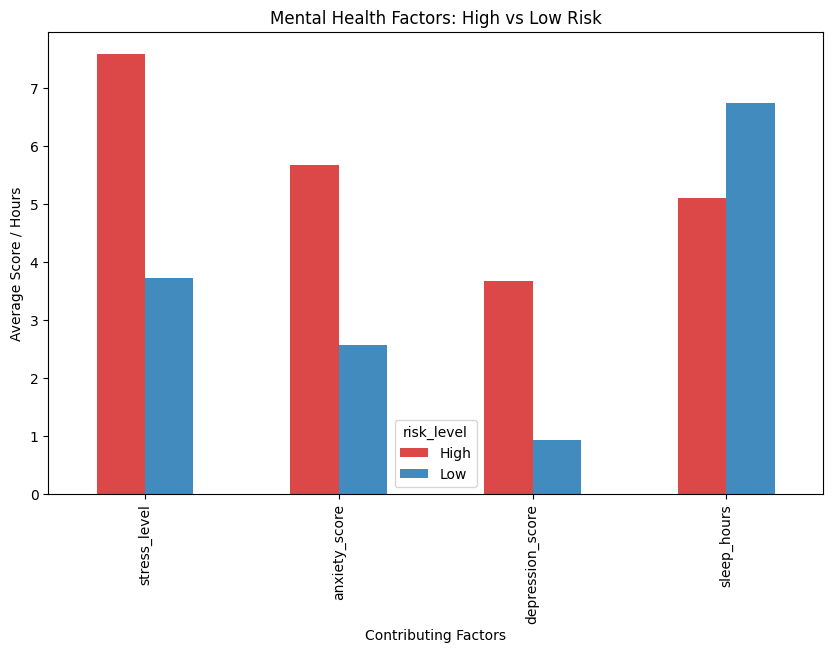

In [ ]:
comparison = df.groupby('risk_level')[
    ['stress_level', 'anxiety_score', 
     'depression_score', 'sleep_hours',
     'burnout_score']
].mean().round(2)
# Adding parameters directly inside the plot function
chart_data = comparison.drop(index='Medium', columns=['burnout_score'])
ax = chart_data.T.plot(
    kind='bar', 
    figsize=(10, 6),
    title='Mental Health Factors: High vs Low Risk',
    xlabel='Contributing Factors',
    ylabel='Average Score / Hours',
    color=["#6d0325", '#1f77b4'], # Hex codes for nice red and blue
    alpha=0.85
)
print(comparison)

## Factors contributing to the burnout_score

Based on the data output above we can clearly see that the depression is the most contributing factor for the burnout score, it's almost 3 times that of the normal low risk students

In [34]:
print(df.columns.tolist())
print(df[df['risk_level']== 'High' ]['gender'].value_counts() )

['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'risk_level', 'dropout_risk', 'z_stress', 'z_anxiety', 'z_depression', 'z_sleep', 'composite_risk', 'predicted_risk']
gender
Female    7270
Male      7242
Other      568
Name: count, dtype: int64


## Final analysis

* Both men and women are almost equally susceptible to burnout_risk while I personally thought otherwise,
I thought one gender could be more suscptible but data proved otherwise
* Based on the correlation with burnout_score stress levels in individuals seems to be the highly contirbuting factors
to the burnout
* But if cross checked with a different method then depression score average had the greatest percentage jump between 
low risk and high risk individuals, high risk individuals has 293% higher average depression scores which is almost 3 times of low risk individuals making it the biggest factor.
* Contrary to individual beliefs increae in screen time had negative correlation with the burnout_score, it could be attributed to the students using smartphones for recreational purposes, which in turn reduced burnout, atleast that's what it is based on the data from this dataset. 
* Students sleeping less than 6 hours per day are also more susceptible to burnout